<a href="https://colab.research.google.com/github/omkulawade03/Dataset/blob/main/heart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [2]:
from google.colab import files

uploaded = files.upload()

Saving heart.csv to heart.csv


In [3]:
filepath = "/content/heart.csv"
df = pd.read_csv("heart.csv")

In [4]:
# --- Q1. Load dataset, display rows, shape, and info ---
print("--- Q1: Data Loading & Basic Info ---")
df = pd.read_csv('heart.csv')
print(df.head(10))

print("\nShape of dataset:", df.shape)
print("\nDataset Info:")
df.info()
print("\n")

--- Q1: Data Loading & Basic Info ---
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   
5   39   M           NAP        120          339          0     Normal    170   
6   45   F           ATA        130          237          0     Normal    170   
7   54   M           ATA        110          208          0     Normal    142   
8   37   M           ASY        140          207          0     Normal    130   
9   48   F           ATA        120          284          0     Normal    120   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N   

In [5]:
# --- Q2. Check for missing values ---
print("--- Q2: Missing Values ---")
print(df.isnull().sum())
print("\n")

--- Q2: Missing Values ---
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64




In [6]:
# --- Q3. Check and remove duplicate rows ---
print("--- Q3: Handling Duplicates ---")
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicates}")

# If duplicates exist, we drop them
if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed! New shape of dataset:", df.shape)
print("\n")

--- Q3: Handling Duplicates ---
Number of duplicate rows found: 0




In [7]:
# --- Q4. Identify invalid values (zeros in BP and Cholesterol) ---
print("--- Q4: Invalid Values Count ---")
chol_zero_count = (df['Cholesterol'] == 0).sum()
bp_zero_count = (df['RestingBP'] == 0).sum()

print(f"Rows with Cholesterol = 0: {chol_zero_count}")
print(f"Rows with RestingBP = 0: {bp_zero_count}")
print("\n")

--- Q4: Invalid Values Count ---
Rows with Cholesterol = 0: 172
Rows with RestingBP = 0: 1




In [8]:
# --- Q5. Clean invalid values ---
print("--- Q5: Cleaning Invalid Values ---")
print("Statistical Summary BEFORE cleaning:")
print(df[['Cholesterol', 'RestingBP']].describe())

# Calculate the mean of these columns, strictly excluding the zeros
mean_chol = df[df['Cholesterol'] > 0]['Cholesterol'].mean()
mean_bp = df[df['RestingBP'] > 0]['RestingBP'].mean()

# Replace the 0s with the calculated means and round to 2 decimal places
df['Cholesterol'] = df['Cholesterol'].replace(0, mean_chol).round(2)
df['RestingBP'] = df['RestingBP'].replace(0, mean_bp).round(2)

print("\nStatistical Summary AFTER cleaning:")
print(df[['Cholesterol', 'RestingBP']].describe())
print("\n")

--- Q5: Cleaning Invalid Values ---
Statistical Summary BEFORE cleaning:
       Cholesterol   RestingBP
count   918.000000  918.000000
mean    198.799564  132.396514
std     109.384145   18.514154
min       0.000000    0.000000
25%     173.250000  120.000000
50%     223.000000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000

Statistical Summary AFTER cleaning:
       Cholesterol   RestingBP
count   918.000000  918.000000
mean    244.636253  132.540893
std      53.318029   17.989932
min      85.000000   80.000000
25%     214.000000  120.000000
50%     244.640000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000




--- Q6: Plotting Histograms... ---


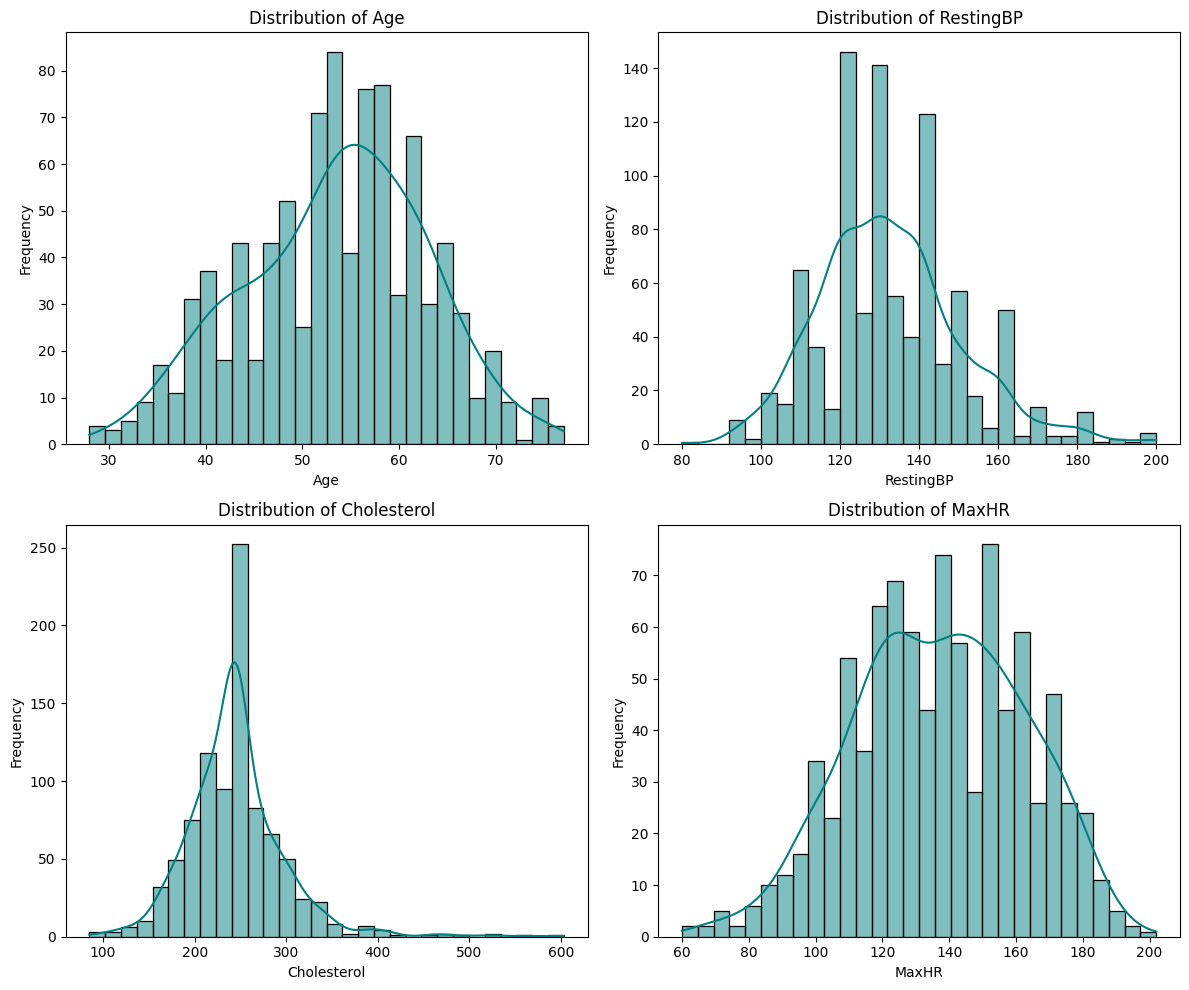

In [9]:
# --- Q6. Function to plot histograms ---
print("--- Q6: Plotting Histograms... ---")
def plot_histograms(data):
    # Create a 2x2 layout figure
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten() # Flatten to loop through easily

    # The columns we want to visualize
    cols_to_plot = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR']

    for i, col in enumerate(cols_to_plot):
        sns.histplot(data[col], kde=True, ax=axes[i], color='teal', bins=30)
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

# Call the function to visualize our newly cleaned data
plot_histograms(df)




In [10]:
# --- Q7. Identify numerical and categorical columns ---
print("--- Q7: Column Types ---")
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)
print("\n")

--- Q7: Column Types ---
Numerical Columns: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease']
Categorical Columns: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']




In [11]:
# --- Q8. One-Hot Encoding ---
print("--- Q8: One-Hot Encoding ---")
# pd.get_dummies converts our categorical text columns into 1s and 0s
df_encoded = pd.get_dummies(df, columns=categorical_cols, dtype=int)

print("Shape of encoded dataframe:", df_encoded.shape)
print("\nFirst 5 rows of encoded dataframe:")
print(df_encoded.head())
print("\n")

--- Q8: One-Hot Encoding ---
Shape of encoded dataframe: (918, 21)

First 5 rows of encoded dataframe:
   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease  \
0   40      140.0        289.0          0    172      0.0             0   
1   49      160.0        180.0          0    156      1.0             1   
2   37      130.0        283.0          0     98      0.0             0   
3   48      138.0        214.0          0    108      1.5             1   
4   54      150.0        195.0          0    122      0.0             0   

   Sex_F  Sex_M  ChestPainType_ASY  ...  ChestPainType_NAP  ChestPainType_TA  \
0      0      1                  0  ...                  0                 0   
1      1      0                  0  ...                  1                 0   
2      0      1                  0  ...                  0                 0   
3      1      0                  1  ...                  0                 0   
4      0      1                  0  ...       

In [12]:
# --- Q9. Final dataframe summary ---
print("--- Q9: Final Dataframe Overview ---")
print("Final Shape of df_encoded:", df_encoded.shape)
print("\nList of all column names:")
print(df_encoded.columns.tolist())

--- Q9: Final Dataframe Overview ---
Final Shape of df_encoded: (918, 21)

List of all column names:
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease', 'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']


In [13]:
# --- Q10: Summary Analysis ---
print("1. Invalid values: Cholesterol = 0 and RestingBP = 0 were replaced with mean values.")
print("2. Importance: Handling invalid values improves data quality and model accuracy.")
print("3. One-Hot Encoding: It converts categorical data into numerical format.")
print("4. Observation: Duplicates and missing values were checked and the dataset was cleaned.")

1. Invalid values: Cholesterol = 0 and RestingBP = 0 were replaced with mean values.
2. Importance: Handling invalid values improves data quality and model accuracy.
3. One-Hot Encoding: It converts categorical data into numerical format.
4. Observation: Duplicates and missing values were checked and the dataset was cleaned.
